# RNN
- RNN은 순서가 있는 데이터를 다룸 -> 시퀀스한 데이터
- 이전 값들의 흐름을 기억하면서 다음 값을 예측
---
### 노이즈가 있는 사인파 데이터 사용해 RNN 예측 모델 작성

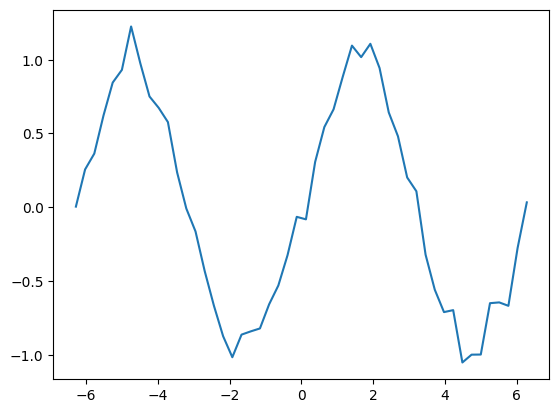

In [24]:
import numpy as np
import matplotlib.pyplot as plt

xdata = np.linspace(-2 * np.pi, 2 * np.pi) # 50개 기본값
# print(xdata) # [-6.28318531 -6.02672876
sindata = np.sin(xdata) + 0.1 * np.random.randn(len(xdata)) # sin함수에 난수로 노이즈 추가
# print('sindata : ', sindata) # [-0.00562295  0.14154501

# 시각화 하기
plt.plot(xdata, sindata)
plt.show()


In [25]:
n_rnn = 10
n_sample = len(xdata) - n_rnn   # 학습 샘플 갯수
x = np.zeros((n_sample, n_rnn)) # 입력 시퀀스를 저장할 배열
t = np.zeros((n_sample, n_rnn)) # 예측 대상 시퀀스를 저장할 배열 - 한칸 뒤로 밀린 값을 정답 t로 생성

for i in range(0, n_sample): # 40
  x[i] = sindata[i : i + n_rnn]
  t[i] = sindata[i + 1 : i + n_rnn + 1]
# print(x[:3])
# print(t[:3])

x = x.reshape(n_sample, n_rnn, 1)  # RNN은 입력을 (샘플수 , 시계열수, 입력층뉴런) 이런 형태를 취함.
print(x.shape) # (40, 10, 1)
t = t.reshape(n_sample, n_rnn, 1)
print(t.shape) # (40, 10, 1)

(40, 10, 1)
(40, 10, 1)


In [26]:
# SimpleRNN 구축
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

n_in = 1    # 입력측 뉴런(노드) 수
n_min = 20  # 중간층(hiddne) 노드 수
n_out = 1   # 출력층 노드 수

model = Sequential()
model.add(
    SimpleRNN(
        n_min,
        input_shape=(n_rnn, n_in),
        return_sequences=True # RNN이 마지막 시점의 결과만 내보내는 것이 아니라 각 시점마다 결과를 출력함. 시계열 전체 예측값을 True로 줌
  )
)
model.add(Dense(n_out, activation='linear'))
print(model.summary())

model.compile(loss='mean_squared_error', optimizer='sgd')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_5 (SimpleRNN)        │ (None, 10, 20)         │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10, 1)          │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 461 (1.80 KB)

 Trainable params: 461 (1.80 KB)

 Non-trainable params: 0 (0.00 B)

None


Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.2165 - val_loss: 0.1735
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1567 - val_loss: 0.1360
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1267 - val_loss: 0.1120
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1092 - val_loss: 0.0964
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0977 - val_loss: 0.0884
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0899 - val_loss: 0.0844
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0842 - val_loss: 0.0799
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0796 - val_loss: 0.0764
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0756 - val_loss: 0.0730
Epoch 10/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0722 - val_loss: 0.0703
Epoch 11/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0696 - val_loss: 0.0673
Epoch 12/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0667 - val_loss: 0.0656
E

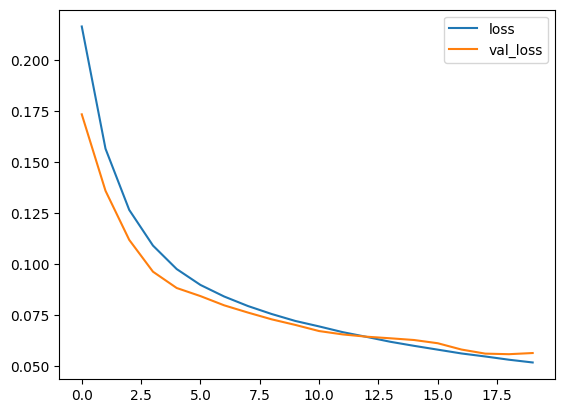

In [27]:
history = model.fit(x, t, epochs=20, batch_size=8, validation_split=0.1)

loss = history.history['loss']
val_loss = history.history['val_loss']
plt.plot(np.arange(len(loss)), loss, label='loss')
plt.plot(np.arange(len(val_loss)), val_loss, label='val_loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━

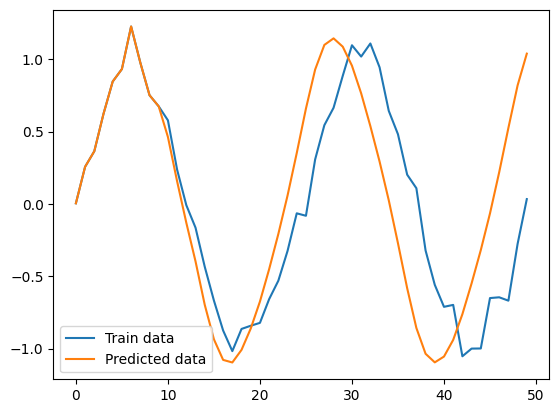

In [28]:
# sin함수 다음값을 예측
pred = x[0].reshape(-1) # 1차원 백터화 - 가장 최근의 시계열 데이터
# print(pred) # [-0.00535016  0.231019

# 총 n_sample 횟수만큼 반복하면서 예측값을 이어 붙이기
for i in range(0, n_sample):
  yhat = model.predict(pred[-n_rnn:].reshape(1, n_rnn, 1))
  pred = np.append(pred, yhat[0][n_rnn -1][0]) # 출력의 최후 결과 추가

plt.plot(np.arange(len(sindata)), sindata, label='Train data')
plt.plot(np.arange(len(pred)), pred, label='Predicted data')
plt.legend()
plt.show()

In [35]:
# 예측값과 실제값 비교
predicted = pred[n_rnn:]
actual = sindata[n_rnn:]
for i in range(10):
  print(f'{i:02d} - 예측:{predicted[i]:.4f}, 실제:{actual[i]:.4f}')

# 오차값 - MSE
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(actual, predicted)
print(f'MSE : {mse:.5f}')

00 - 예측:0.4624, 실제:0.5772
01 - 예측:0.1559, 실제:0.2362
02 - 예측:-0.1306, 실제:-0.0089
03 - 예측:-0.3969, 실제:-0.1643
04 - 예측:-0.6965, 실제:-0.4337
05 - 예측:-0.9356, 실제:-0.6680
06 - 예측:-1.0778, 실제:-0.8747
07 - 예측:-1.0956, 실제:-1.0172
08 - 예측:-1.0085, 실제:-0.8638
09 - 예측:-0.8611, 실제:-0.8418
MSE : 0.30180
